# Traditional Sensor Fusion & Data Association



---

### Learning Objectives
1. Derive and implement **precision-weighted fusion** (MLE) for scalar and multivariate cases
2. Understand fusion through the **entropy / information** lens
3. Implement a **Kalman Filter** as Bayesian fusion with sequential multi-sensor updates
4. Quantify and correct **correlated sensor noise** and use **Covariance Intersection**
5. Implement **ellipsoidal gating** (Mahalanobis) and understand χ² thresholds
6. Build and compare **GNN, PDAF, JPDA** data-association methods on crossing targets
7. Implement a **GM-PHD filter** for variable-cardinality tracking
8. Perform **sensor registration** (bias estimation) and **track-to-track fusion**

### Prerequisites
- Linear algebra, probability, basic Python / NumPy
- Familiarity with Gaussian distributions and Bayes' rule

### How This Maps to the Slides

| Slide Block | Slide Topics | Notebook Section |
|---|---|---|
| **Block 1** — Optimal Multi-Sensor Fusion | MLE derivation, precision weighting, entropy, multivariate, N sensors, correlated noise | §1 – §4 |
| **Block 2** — Bayesian Fusion | KF as fusion, sequential vs stacked, information form, CI, PoE | §5 – §8 |
| **Block 3** — Data Association | Gating, GNN, PDAF, JPDA, MHT comparison | §9 – §13 |
| **Appendix** | Mahalanobis distance | §9 (gating) |


## Setup


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import chi2, norm, multivariate_normal
from scipy.optimize import minimize_scalar, linear_sum_assignment
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({'figure.figsize': (9, 5), 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.3})

print("Environment ready. NumPy", np.__version__)


Environment ready. NumPy 2.0.2


---
## §1  Precision-Weighted Fusion of Two Noisy Sensors (Scalar)

**Slide coverage:** Block 1 — "The Fusion Problem: Setup", "Derivation: Maximum Likelihood"

### Problem Statement
Two sensors independently measure the same scalar quantity $x$:
$$z_1 = x + v_1, \quad v_1 \sim \mathcal{N}(0, \sigma_1^2)$$
$$z_2 = x + v_2, \quad v_2 \sim \mathcal{N}(0, \sigma_2^2)$$

**Goal:** Find the minimum-variance unbiased linear estimate $\hat{x} = w_1 z_1 + w_2 z_2$.

### Mathematical Formulation
From MLE (setting $\partial \log p / \partial x = 0$):
$$\hat{x} = \frac{\lambda_1 z_1 + \lambda_2 z_2}{\lambda_1 + \lambda_2}, \quad \sigma_f^{-2} = \lambda_1 + \lambda_2$$
where $\lambda_i = 1/\sigma_i^2$ are the precisions.


In [ ]:
# --- Problem 1: Scalar precision-weighted fusion ---
# Parameters (from slide analytical example)
sigma1, sigma2 = 2.0, 1.0
x_true = 5.0
z1, z2 = 4.8, 5.3

# Step 1: Precisions
lam1, lam2 = 1/sigma1**2, 1/sigma2**2
lam_f = lam1 + lam2
print(f"Precisions:  lambda_1 = {lam1:.4f},  lambda_2 = {lam2:.4f},  lambda_f = {lam_f:.4f}")

# Step 2: Weights
w1, w2 = lam1/lam_f, lam2/lam_f
print(f"Weights:     w_1 = {w1:.4f},  w_2 = {w2:.4f},  sum = {w1+w2:.4f}")

# Step 3: Fused estimate
x_hat = w1*z1 + w2*z2
print(f"Fused est:   x_hat = {w1:.2f}*{z1} + {w2:.2f}*{z2} = {x_hat:.4f}")

# Step 4: Fused variance
sigma_f = (1/lam_f)**0.5
print(f"Fused sigma_f  = {sigma_f:.4f}  (< sigma_2={sigma2} < sigma_1={sigma1})  CHECK")

# Errors
print(f"\nErrors:  sensor 1 = |{z1}-{x_true}| = {abs(z1-x_true):.2f}")
print(f"         sensor 2 = |{z2}-{x_true}| = {abs(z2-x_true):.2f}")
print(f"         fused    = |{x_hat}-{x_true}| = {abs(x_hat-x_true):.2f}")


Precisions:  lambda_1 = 0.2500,  lambda_2 = 1.0000,  lambda_f = 1.2500
Weights:     w_1 = 0.2000,  w_2 = 0.8000,  sum = 1.0000
Fused est:   x_hat = 0.20*4.8 + 0.80*5.3 = 5.2000
Fused sigma_f  = 0.8944  (< sigma_2=1.0 < sigma_1=2.0)  CHECK

Errors:  sensor 1 = |4.8-5.0| = 0.20
         sensor 2 = |5.3-5.0| = 0.30
         fused    = |5.2-5.0| = 0.20


Monte Carlo RMSE comparison (50k trials):
  Sensor 1 RMSE = 2.0003  (theory: 2.0)
  Sensor 2 RMSE = 1.0016  (theory: 1.0)
  Fused    RMSE = 0.8927  (theory: 0.8944)


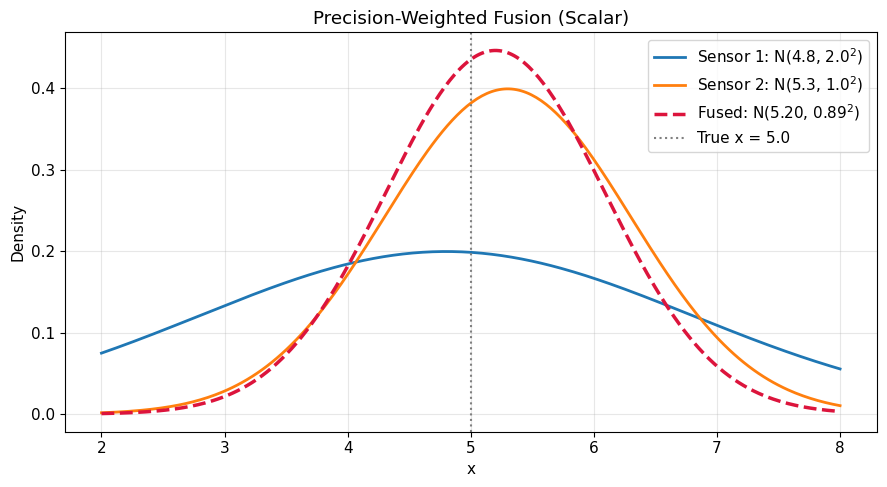

In [ ]:
# Monte Carlo validation
n_mc = 50000
z1_mc = x_true + sigma1 * np.random.randn(n_mc)
z2_mc = x_true + sigma2 * np.random.randn(n_mc)
xhat_mc = w1 * z1_mc + w2 * z2_mc

print("Monte Carlo RMSE comparison (50k trials):")
print(f"  Sensor 1 RMSE = {np.std(z1_mc - x_true):.4f}  (theory: {sigma1})")
print(f"  Sensor 2 RMSE = {np.std(z2_mc - x_true):.4f}  (theory: {sigma2})")
print(f"  Fused    RMSE = {np.std(xhat_mc - x_true):.4f}  (theory: {sigma_f:.4f})")

# Plot posteriors
xgrid = np.linspace(2, 8, 300)
fig, ax = plt.subplots()
ax.plot(xgrid, norm.pdf(xgrid, z1, sigma1), label=f'Sensor 1: N({z1}, {sigma1}$^2$)', lw=2)
ax.plot(xgrid, norm.pdf(xgrid, z2, sigma2), label=f'Sensor 2: N({z2}, {sigma2}$^2$)', lw=2)
ax.plot(xgrid, norm.pdf(xgrid, x_hat, sigma_f), '--', label=f'Fused: N({x_hat:.2f}, {sigma_f:.2f}$^2$)', lw=2.5, color='crimson')
ax.axvline(x_true, color='gray', ls=':', label=f'True x = {x_true}')
ax.set_xlabel('x'); ax.set_ylabel('Density')
ax.set_title('Precision-Weighted Fusion (Scalar)')
ax.legend(); plt.tight_layout(); plt.show()


---
## §2  Fusion Weights as Soft Exclusion

**Slide coverage:** Block 1 — "Fusion Weights as Soft Exclusion"

The weight on sensor 1 is $w_1 = \sigma_2^2 / (\sigma_1^2 + \sigma_2^2)$. As sensor 1 degrades ($\sigma_1 \to \infty$), $w_1 \to 0$ — automatic soft exclusion with no thresholds.


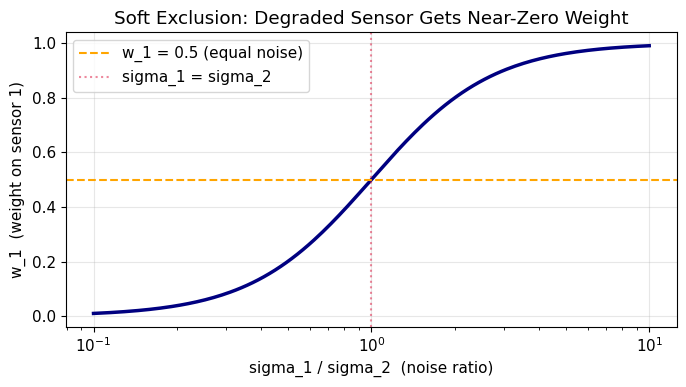

Key: no if-statements, no thresholds -- precision weighting does the job.


In [ ]:
# Weight vs noise ratio
ratio = np.logspace(-1, 1, 200)  # sigma1/sigma2
w1_curve = 1 / (1 + (1/ratio)**2)

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(ratio, w1_curve, lw=2.5, color='navy')
ax.axhline(0.5, ls='--', color='orange', label='w_1 = 0.5 (equal noise)')
ax.axvline(1.0, ls=':', color='crimson', alpha=0.5, label='sigma_1 = sigma_2')
ax.set_xlabel('sigma_1 / sigma_2  (noise ratio)')
ax.set_ylabel('w_1  (weight on sensor 1)')
ax.set_title('Soft Exclusion: Degraded Sensor Gets Near-Zero Weight')
ax.legend(); plt.tight_layout(); plt.show()
print("Key: no if-statements, no thresholds -- precision weighting does the job.")


---
## §3  The Information and Entropy View

**Slide coverage:** Block 1 — "The Information and Entropy View"

Differential entropy of $\mathcal{N}(\mu, \sigma^2)$: $H = \frac{1}{2}\log(2\pi e\, \sigma^2)$.

Information gain from adding sensor 2:
$$\Delta I = \frac{1}{2} \log\frac{\sigma_1^2}{\sigma_f^2} = \frac{1}{2} \log\left(1 + \frac{\lambda_2}{\lambda_1}\right) \geq 0$$


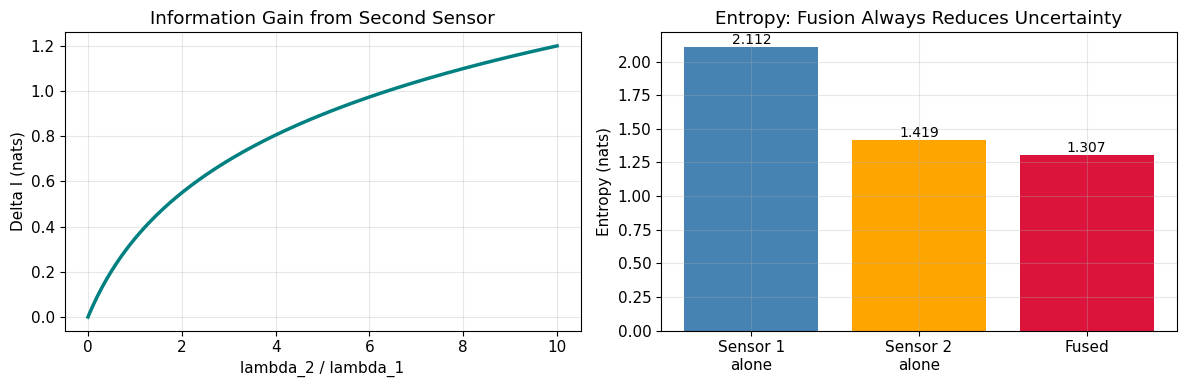

Information gain Delta_I = 0.8047 nats
Fusion always reduces entropy (always informative).


In [ ]:
# Information gain as function of lambda_2/lambda_1
r = np.linspace(0, 10, 200)
delta_I = 0.5 * np.log(1 + r)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(r, delta_I, lw=2.5, color='teal')
axes[0].set_xlabel('lambda_2 / lambda_1'); axes[0].set_ylabel('Delta I (nats)')
axes[0].set_title('Information Gain from Second Sensor')

# Entropy reduction for our example
H_s1 = 0.5 * np.log(2*np.pi*np.e*sigma1**2)
H_fused = 0.5 * np.log(2*np.pi*np.e*sigma_f**2)
H_s2 = 0.5 * np.log(2*np.pi*np.e*sigma2**2)

bars = axes[1].bar(['Sensor 1\nalone', 'Sensor 2\nalone', 'Fused'],
                    [H_s1, H_s2, H_fused], color=['steelblue','orange','crimson'])
axes[1].set_ylabel('Entropy (nats)')
axes[1].set_title('Entropy: Fusion Always Reduces Uncertainty')
for b, v in zip(bars, [H_s1, H_s2, H_fused]):
    axes[1].text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.3f}', ha='center', fontsize=10)
plt.tight_layout(); plt.show()

print(f"Information gain Delta_I = {H_s1 - H_fused:.4f} nats")
print("Fusion always reduces entropy (always informative).")


---
## §4  N Sensors, the 1/sqrt(N) Law, and Correlated Noise


## Theory

**Independent sensors.** If $N$ identical sensors each have zero‑mean noise with variance $\sigma^2$ and are independent, the simple average
$
\hat{x} \;=\; \frac{1}{N}\sum_{i=1}^N z_i
$
has error variance $\operatorname{Var}(\hat{x}-x_{\text{true}})=\sigma^2/N$, so the normalized standard deviation is
$
\frac{\sigma_f}{\sigma}=\frac{1}{\sqrt{N}}.
$

**Correlated sensors.** If sensor noises are *equi‑correlated* with pairwise correlation $\rho\in[0,1)$:
$
\mathrm{Var}(n_i)=\sigma^2,\qquad \mathrm{Corr}(n_i,n_j)=\rho\ \ (i\ne j),
$
we can write a **common‑mode + independent** decomposition:
$
n_i \;=\; \sigma\Big(\sqrt{\rho}\,c + \sqrt{1-\rho}\,\varepsilon_i\Big),\quad
c\sim\mathcal N(0,1),\ \varepsilon_i\stackrel{\text{iid}}{\sim}\mathcal N(0,1).
$
Then the averaged estimator has
$
\operatorname{Var}(\hat{x}-x_{\text{true}})
\;=\; \sigma^2\!\left(\frac{1-\rho}{N}+\rho\right),
\qquad
\boxed{\;\frac{\sigma_f}{\sigma}=\sqrt{\frac{1-\rho}{N}+\rho}\;}
$
which **reduces to $1/\sqrt{N}$** when $\rho=0$ and **saturates** at the **correlation floor**
$
\boxed{\;\lim_{N\to\infty}\frac{\sigma_f}{\sigma}=\sqrt{\rho}\;}
$
when $N$ grows.

**Estimating $\rho$.**
- From an observed large‑$N$ **floor** $\alpha=\sigma_f/\sigma$: $\ \hat\rho \approx \alpha^2$.
- From data at a fixed time: use the **mean off‑diagonal sample correlation** across sensors
  $
  \widehat{\rho}\;=\;\frac{1}{N(N-1)}\sum_{i\ne j}\widehat{\mathrm{Corr}}(n_i,n_j),
  $
  ideally after removing any fixed biases.

---

## What the Monte Carlo simulation does

1. **Fix** $N$, $\sigma$, and $\rho$.  
2. **Generate** many trials of correlated sensor noise using  
   $n_i=\sigma\big(\sqrt{\rho}\,c+\sqrt{1-\rho}\,\varepsilon_i\big)$.  
3. **Form** measurements $z_i=x_{\text{true}}+n_i$ and the **fused average** $\hat{x}=\frac{1}{N}\sum_i z_i$.  
4. **Compute** the empirical RMSE of $\hat{x}$ over trials; this estimates $\sigma_f$.  
5. **Normalize** by $\sigma$ to get $\sigma_f/\sigma$ and **compare** to theory  
   $\sqrt{(1-\rho)/N+\rho}$ (and the uncorrelated baseline $1/\sqrt{N}$).  
6. **Optionally estimate** $\rho$ from the simulated noise by averaging pairwise sample correlations to verify the target $\rho$.



Target rho = 0.12250 | Empirical rho (N=12) ≈ 0.12367


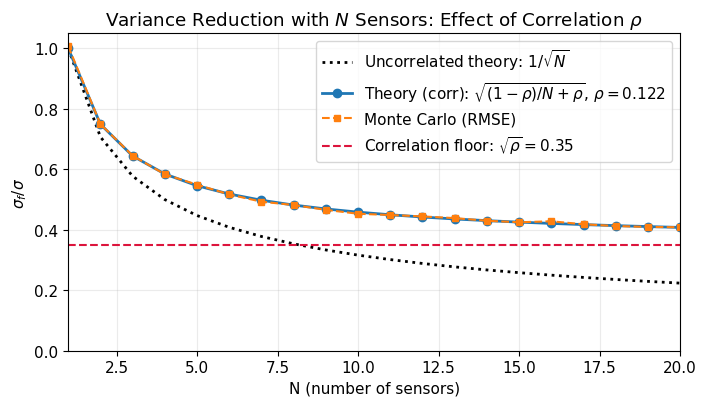

In [ ]:
# 4a: 1/sqrt(N) law demonstration
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
rng = np.random.default_rng(0)

# --- Parameters --------------------------------------------------------------
sigma = 2.0                 # per-sensor standard deviation
rho   = 0.1225              # pairwise correlation (gives floor ≈ sqrt(0.1225)=0.35)
N_vals = np.arange(1, 21)   # number of sensors
n_mc   = 20000               # Monte Carlo trials
x_true = 0.0

# --- Simulation helpers ------------------------------------------------------
def sample_correlated_noise(n_samples: int, N: int, sigma: float, rho: float, rng) -> np.ndarray:
    """
    Generate n_samples x N matrix of zero-mean Gaussian noise with:
      Var(n_i) = sigma^2,  Corr(n_i, n_j) = rho (i != j).
    Construct via common-mode + independent components:
      n_i = sigma*( sqrt(rho)*c + sqrt(1-rho)*eps_i )
    where c ~ N(0,1) shared across sensors, eps_i ~ N(0,1) iid.
    """
    if not (0 <= rho < 1):
        raise ValueError("rho must be in [0, 1).")
    c   = rng.standard_normal(size=(n_samples, 1))
    eps = rng.standard_normal(size=(n_samples, N))
    return sigma * (np.sqrt(rho) * c + np.sqrt(1 - rho) * eps)

def monte_carlo_rmse_ratio(N_vals, sigma, rho, n_mc, x_true, rng):
    """Return array of Monte Carlo estimates of sigma_f/sigma for each N."""
    ratios = []
    for N in N_vals:
        noise = sample_correlated_noise(n_mc, N, sigma, rho, rng)
        zs = x_true + noise
        xhat = zs.mean(axis=1)
        sigma_f_hat = np.std(xhat - x_true, ddof=0)  # population std
        ratios.append(sigma_f_hat / sigma)
    return np.array(ratios)

# --- Monte Carlo and theory --------------------------------------------------
rmse_mc_ratio = monte_carlo_rmse_ratio(N_vals, sigma, rho, n_mc, x_true, rng)

# Theory with correlation: sigma_f/sigma = sqrt((1 - rho)/N + rho)
theory_corr = np.sqrt((1 - rho) / N_vals + rho)

# Uncorrelated baseline (rho=0): sigma_f/sigma = 1/sqrt(N)
theory_uncorr = 1 / np.sqrt(N_vals)

# --- Optional: empirical estimate of rho from simulated noise ----------------
# Use a "large N" case to estimate average pairwise correlation.
N_probe = 12
noise_probe = sample_correlated_noise(n_mc, N_probe, sigma, rho, rng)
# sample correlation matrix across sensors (columns)
corr_mat = np.corrcoef(noise_probe, rowvar=False)
rho_empirical = (np.sum(corr_mat) - np.trace(corr_mat)) / (N_probe*(N_probe-1))

print(f"Target rho = {rho:.5f} | Empirical rho (N={N_probe}) ≈ {rho_empirical:.5f}")

# --- Plot --------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.2, 4.2))

ax.plot(N_vals, theory_uncorr, 'k:', lw=2, label=r'Uncorrelated theory: $1/\sqrt{N}$')
ax.plot(N_vals, theory_corr, 'C0-', lw=2, marker='o',
        label=rf'Theory (corr): $\sqrt{{(1-\rho)/N+\rho}}$, $\rho={rho:.3f}$')
ax.plot(N_vals, rmse_mc_ratio, 'C1--', marker='s', ms=4, label='Monte Carlo (RMSE)')

# Correlation floor at sqrt(rho)
ax.axhline(np.sqrt(rho), ls='--', color='crimson',
           label=rf'Correlation floor: $\sqrt{{\rho}}={np.sqrt(rho):.2f}$')

ax.set_xlabel('N (number of sensors)')
ax.set_ylabel(r'$\sigma_f / \sigma$')
ax.set_title(r'Variance Reduction with $N$ Sensors: Effect of Correlation $\rho$')
ax.set_xlim(N_vals.min(), N_vals.max())
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 4b: Correlated noise -- naive vs correct fusion
sigma_u = 1.0   # common-mode noise
sigma_e = 1.5   # independent noise per sensor
sigma_total = np.sqrt(sigma_u**2 + sigma_e**2)
Sigma12 = sigma_u**2

sigma_f_correct = np.sqrt(
    (sigma_total**2 * sigma_total**2 - Sigma12**2) /
    (sigma_total**2 + sigma_total**2 - 2*Sigma12)
)
sigma_f_naive = sigma_total / np.sqrt(2)  # pretend independent

print("Correlated noise scenario:")
print(f"  Per-sensor sigma = {sigma_total:.3f}")
print(f"  Cross-covariance Sigma_12 = {Sigma12:.3f}")
print(f"  Correct fused sigma_f    = {sigma_f_correct:.3f}")
print(f"  Naive (ignore corr.)     = {sigma_f_naive:.3f}")
print(f"  Overconfidence ratio     = {sigma_f_naive/sigma_f_correct:.3f}")
print("\nWARNING: Naive fusion underestimates uncertainty -> filter divergence!")

# MC verification
n_mc = 50000
u = sigma_u * np.random.randn(n_mc)
e1 = sigma_e * np.random.randn(n_mc)
e2 = sigma_e * np.random.randn(n_mc)
z1_corr = x_true + u + e1
z2_corr = x_true + u + e2
x_naive = 0.5*(z1_corr + z2_corr)
print(f"\nMC: actual fused RMSE = {np.std(x_naive-x_true):.3f} (matches correct = {sigma_f_correct:.3f})")


Correlated noise scenario:
  Per-sensor sigma = 1.803
  Cross-covariance Sigma_12 = 1.000
  Correct fused sigma_f    = 1.458
  Naive (ignore corr.)     = 1.275
  Overconfidence ratio     = 0.874


MC: actual fused RMSE = 1.459 (matches correct = 1.458)


---
## §5  Multivariate Precision-Weighted Fusion

**Slide coverage:** Block 1 — "Multivariate Fusion", Block 2 — "Information Form: Precision Additivity"

For two sensors measuring the full state with $H_i = I$:
$$\Sigma_f^{-1} = \Sigma_1^{-1} + \Sigma_2^{-1}, \quad \mu_f = \Sigma_f (\Sigma_1^{-1} y_1 + \Sigma_2^{-1} y_2)$$


Sensor 1:  mu_1 = [2.5 4.8]  det(Sigma_1) = 7.000
Sensor 2:  mu_2 = [3.2 5.5]  det(Sigma_2) = 2.910
Fused:     mu_f = [3.114 5.168]  det(Sigma_f) = 0.831

Entropy reduction confirmed: det(Sigma_f) < min(det(Sigma_1), det(Sigma_2))


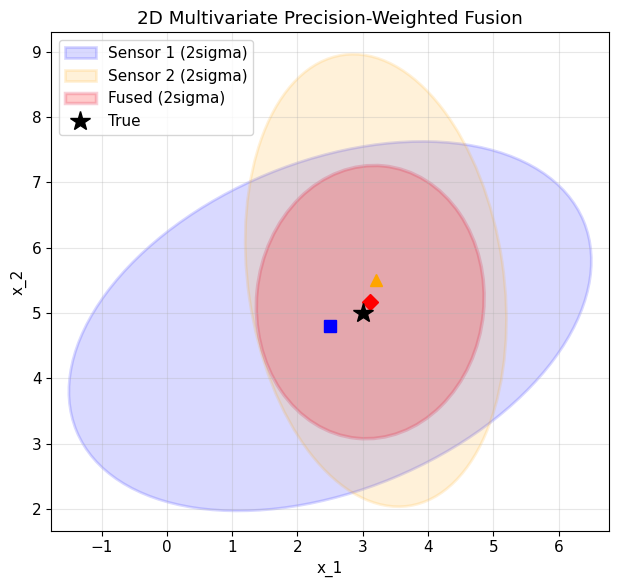

In [ ]:
# 2D multivariate fusion example
mu_true_2d = np.array([3.0, 5.0])
Sigma1_2d = np.array([[4.0, 1.0],[1.0, 2.0]])
Sigma2_2d = np.array([[1.0, -0.3],[-0.3, 3.0]])

y1_2d = np.array([2.5, 4.8])
y2_2d = np.array([3.2, 5.5])

# Information form fusion
Lambda1 = np.linalg.inv(Sigma1_2d)
Lambda2 = np.linalg.inv(Sigma2_2d)
Lambda_f = Lambda1 + Lambda2
Sigma_f_2d = np.linalg.inv(Lambda_f)
mu_f_2d = Sigma_f_2d @ (Lambda1 @ y1_2d + Lambda2 @ y2_2d)

print("Sensor 1:  mu_1 =", y1_2d, " det(Sigma_1) =", f"{np.linalg.det(Sigma1_2d):.3f}")
print("Sensor 2:  mu_2 =", y2_2d, " det(Sigma_2) =", f"{np.linalg.det(Sigma2_2d):.3f}")
print("Fused:     mu_f =", np.round(mu_f_2d, 3), " det(Sigma_f) =", f"{np.linalg.det(Sigma_f_2d):.3f}")
print("\nEntropy reduction confirmed: det(Sigma_f) < min(det(Sigma_1), det(Sigma_2))")

# Visualization
def plot_cov_ellipse(ax, mu, Sigma, n_std=2, **kwargs):
    w, V = np.linalg.eigh(Sigma)
    angle = np.degrees(np.arctan2(V[1,1], V[0,1]))
    ell = Ellipse(xy=mu, width=2*n_std*np.sqrt(w[1]),
                  height=2*n_std*np.sqrt(w[0]), angle=angle, **kwargs)
    ax.add_patch(ell)

fig, ax = plt.subplots(figsize=(7, 6))
plot_cov_ellipse(ax, y1_2d, Sigma1_2d, facecolor='blue', alpha=0.15, edgecolor='blue', lw=2, label='Sensor 1 (2sigma)')
plot_cov_ellipse(ax, y2_2d, Sigma2_2d, facecolor='orange', alpha=0.15, edgecolor='orange', lw=2, label='Sensor 2 (2sigma)')
plot_cov_ellipse(ax, mu_f_2d, Sigma_f_2d, facecolor='red', alpha=0.2, edgecolor='crimson', lw=2.5, label='Fused (2sigma)')
ax.plot(*mu_true_2d, 'k*', ms=15, label='True', zorder=5)
ax.plot(*y1_2d, 'bs', ms=8); ax.plot(*y2_2d, '^', color='orange', ms=8)
ax.plot(*mu_f_2d, 'rD', ms=8)
ax.set_aspect('equal'); ax.legend(); ax.set_title('2D Multivariate Precision-Weighted Fusion')
ax.set_xlabel('x_1'); ax.set_ylabel('x_2')
plt.tight_layout(); plt.show()


---
## §6  Kalman Filter as Bayesian Fusion, sequential update — 1D Velocity Tracking -

**Slide coverage:** Block 2 — "Kalman Filter as Bayesian Fusion", "Sequential vs Stacked Updates"


# Kalman Filter as Bayesian Fusion — 1D Velocity Tracking (Model + Sequential Fusion)

**Goal.** Estimate a 1‑D state
$
\mathbf{x}_k=\begin{bmatrix}p_k\\ v_k\end{bmatrix}
$
(position `p`, velocity `v`) using **two modalities**:
- an **IMU‑like velocity measurement** at **every** time step, and
- a **GPS position measurement** at **every 5th** time step.

We implement **sequential fusion**: at each step we (1) **predict** with the motion model, then (2) **apply one KF measurement update per available sensor** in that step—IMU always, GPS only when it arrives.

---

## 1) The probabilistic model used by the program

### 1.1 State‐space dynamics (constant‑velocity model)

- Discrete time step: $\Delta t = 0.1$.
- Linear transition:
 $
  \mathbf{F}=
  \begin{bmatrix}
  1 & \Delta t\\[2pt]
  0 & 1
  \end{bmatrix},\qquad
  \mathbf{x}_{k}=\mathbf{F}\,\mathbf{x}_{k-1}+\mathbf{q}_{k}.
  $
- Process noise (integrated white acceleration):
 $
  \mathbf{q}_k\sim\mathcal N(\mathbf{0},\,\mathbf{Q}),\quad
  \mathbf{Q}=
  q\begin{bmatrix}
  \tfrac{\Delta t^3}{3} & \tfrac{\Delta t^2}{2}\\[4pt]
  \tfrac{\Delta t^2}{2} & \Delta t
  \end{bmatrix},\;\; q=0.5.
  $
  **Why this $Q$?** It models uncertainty due to unmodeled accelerations. Position variance grows roughly with $\Delta t^3$, velocity with $\Delta t$, and their covariance with $\Delta t^2/2$.

**Interpretation for the filter.**  
- $Q$ makes the prediction covariance $\mathbf{P}$ increase each step (“we become less certain” between measurements).  
- The off‑diagonal terms of $P$ couple $p$ and $v$: information about one helps the other during updates.

---

### 1.2 Measurement models (two modalities)

- **IMU (velocity) each step**
$
  \mathbf{H}_{\text{imu}}=\begin{bmatrix}0 & 1\end{bmatrix},\quad
  y^{\text{imu}}_k = \mathbf{H}_{\text{imu}}\mathbf{x}_k + r^{\text{imu}}_k,\quad
  r^{\text{imu}}_k\sim\mathcal N(0,\mathbf{R}_{\text{imu}}),
  $
  with $\mathbf{R}_{\text{imu}} = [\,0.5^2\,]$.

- **GPS (position) every 5th step**
 $
  \mathbf{H}_{\text{gps}}=\begin{bmatrix}1 & 0\end{bmatrix},\quad
  y^{\text{gps}}_k = \mathbf{H}_{\text{gps}}\mathbf{x}_k + r^{\text{gps}}_k,\quad
  r^{\text{gps}}_k\sim\mathcal N(0,\mathbf{R}_{\text{gps}}),
  $
  with $\mathbf{R}_{\text{gps}} = [\,2.0^2\,]$.

**Asynchrony.**  
- IMU **always available** → constrains velocity at every step.  
- GPS **infrequent** (every 5 steps) → periodically re‑anchors position (and indirectly velocity via cross‑covariance).

---

## 2) The sequential fusion algorithm (what the loop does)

At time step $k$:

1) **Predict (time update)**  
   $
   \boldsymbol{\mu}_{k|k-1}=\mathbf{F}\boldsymbol{\mu}_{k-1|k-1},\qquad
   \mathbf{P}_{k|k-1}=\mathbf{F}\mathbf{P}_{k-1|k-1}\mathbf{F}^\top+\mathbf{Q}.
   $

2) **Update with IMU (velocity) — always**  
  $
   \mathbf{S}=\mathbf{H}_{\text{imu}}\mathbf{P}\mathbf{H}_{\text{imu}}^\top+\mathbf{R}_{\text{imu}},\quad
   \mathbf{K}=\mathbf{P}\mathbf{H}_{\text{imu}}^\top\mathbf{S}^{-1},
  $
  $
   \boldsymbol{\mu}\leftarrow \boldsymbol{\mu}+\mathbf{K}\,\big(y^{\text{imu}}_k-\mathbf{H}_{\text{imu}}\boldsymbol{\mu}\big),\quad
   \mathbf{P}\leftarrow (\mathbf{I}-\mathbf{K}\mathbf{H}_{\text{imu}})\mathbf{P}.
  $

3) **Update with GPS (position) — only if $k\equiv 0\pmod 5$**  
   Same equations with $(\mathbf{H}_{\text{gps}}, \mathbf{R}_{\text{gps}}, y^{\text{gps}}_k)$.

**Why this works (intuition).**
- The **IMU update** directly reduces velocity uncertainty. Because $P$ has off‑diagonal terms, this also nudges position uncertainty down.  
- Without GPS, **position** uncertainty would gradually **grow** (process noise + integration).  
- When a **GPS fix** arrives, it causes a **sharp drop** in position uncertainty (and a smaller drop in velocity via cross‑covariance).  
- Over time, alternating IMU‑every‑step and GPS‑every‑5th keeps both $p$ and $v$ well‑constrained.

---

## 3) How the code maps to the math

- `F`, `Q` → motion model.  
- `H_imu`, `R_imu`; `H_gps`, `R_gps` → measurement models/noises.  
- `mu_kf`, `P_kf` → $\boldsymbol{\mu}$, $\mathbf{P}$.  
- `S_*`, `K_*`, `innov_*` → innovation covariance $\mathbf{S}$, Kalman gain $\mathbf{K}$, and residual.  
- **Order** on GPS steps: *predict → IMU update → GPS update*. Under independent noises this is equivalent to any order (or to a single joint update), but keeping IMU first is natural since it always arrives.

---

## 4) Why not “IMU only”?

- With only IMU (velocity), $v$ would be accurate, but **position** is obtained by integrating velocity and thus drifts with process noise.  
- GPS fixes—even infrequent—**re‑anchor position**, preventing unbounded growth of its covariance and correcting accumulated drift.



In [ ]:
# --- KF 1D tracking with IMU + GPS ---
dt = 0.1
F = np.array([[1, dt],[0, 1]])
Q = np.array([[dt**3/3, dt**2/2],[dt**2/2, dt]]) * 0.5

H_imu = np.array([[0, 1]])    # measures velocity
R_imu = np.array([[0.5**2]])

H_gps = np.array([[1, 0]])    # measures position
R_gps = np.array([[2.0**2]])

# True trajectory
T = 100
x_true_kf = np.zeros((T, 2))
x_true_kf[0] = [0, 2.0]
for k in range(1, T):
    x_true_kf[k] = F @ x_true_kf[k-1] + np.array([0, 0.02*np.sin(0.1*k)])

# Generate measurements
z_imu = x_true_kf[:, 1:2] + 0.5*np.random.randn(T, 1)
z_gps = x_true_kf[:, 0:1] + 2.0*np.random.randn(T, 1)

# --- Run KF with sequential updates ---
mu_kf = np.array([0.0, 0.0])
P_kf = np.diag([10.0, 5.0])
est_seq = np.zeros((T, 2))
P_trace_seq = np.zeros(T)
innovations = []

for k in range(T):
    # Predict
    mu_kf = F @ mu_kf
    P_kf = F @ P_kf @ F.T + Q

    # Update 1: IMU (every step)
    S_imu = H_imu @ P_kf @ H_imu.T + R_imu
    K_imu = P_kf @ H_imu.T @ np.linalg.inv(S_imu)
    innov_imu = z_imu[k] - H_imu @ mu_kf
    mu_kf = mu_kf + (K_imu @ innov_imu).flatten()
    P_kf = (np.eye(2) - K_imu @ H_imu) @ P_kf

    # Update 2: GPS (every 5th step)
    if k % 5 == 0:
        S_gps = H_gps @ P_kf @ H_gps.T + R_gps
        K_gps = P_kf @ H_gps.T @ np.linalg.inv(S_gps)
        innov_gps = z_gps[k] - H_gps @ mu_kf
        mu_kf = mu_kf + (K_gps @ innov_gps).flatten()
        P_kf = (np.eye(2) - K_gps @ H_gps) @ P_kf
        innovations.append((k, float(innov_gps.flat[0]), float(S_gps.flat[0])))

    est_seq[k] = mu_kf
    P_trace_seq[k] = np.trace(P_kf)

print(f"Final position error: {abs(est_seq[-1,0]-x_true_kf[-1,0]):.3f} m")
print(f"Final velocity error: {abs(est_seq[-1,1]-x_true_kf[-1,1]):.3f} m/s")
print(f"Final covariance trace: {P_trace_seq[-1]:.4f}")


Final position error: 0.434 m
Final velocity error: 0.225 m/s
Final covariance trace: 0.3681


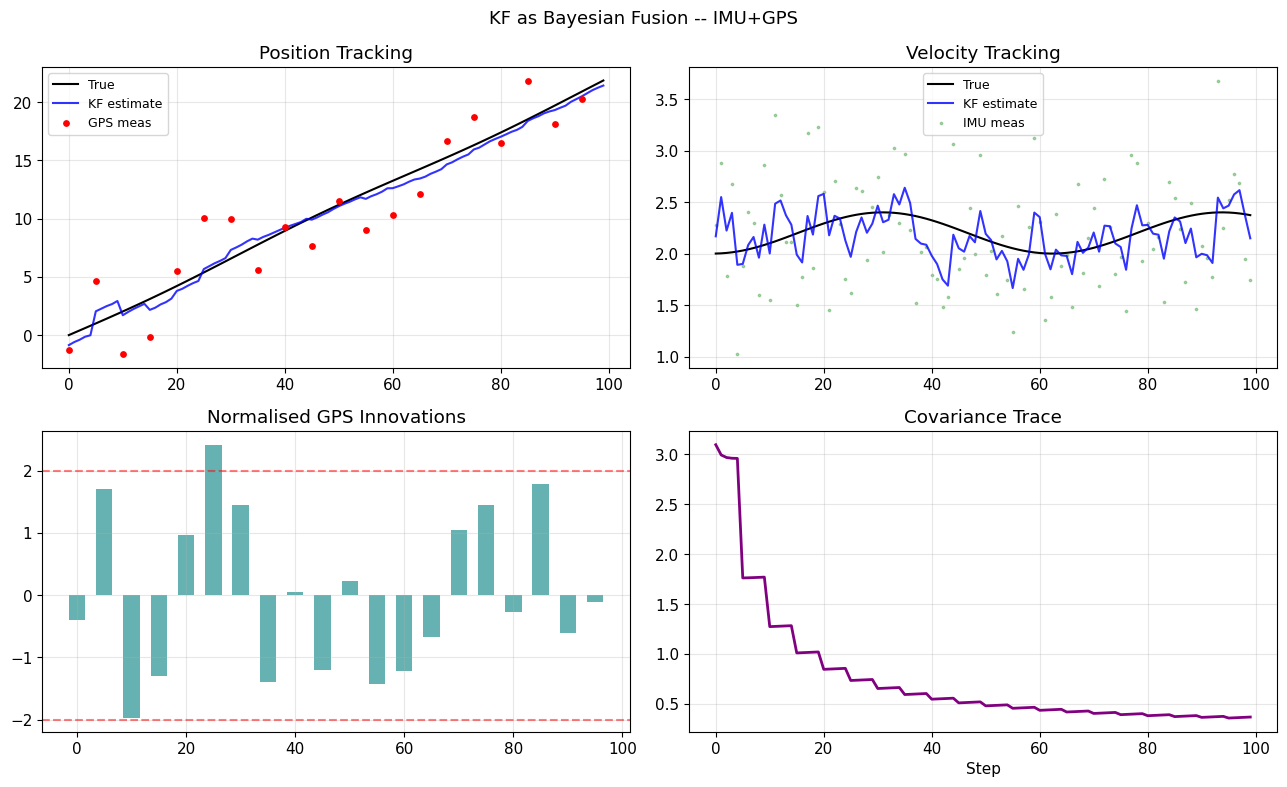

In [ ]:
# KF diagnostics plots
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0,0].plot(x_true_kf[:,0], 'k-', label='True', lw=1.5)
axes[0,0].plot(est_seq[:,0], 'b-', label='KF estimate', alpha=0.8)
gps_steps = np.arange(0, T, 5)
axes[0,0].scatter(gps_steps, z_gps[gps_steps, 0], s=15, c='red', label='GPS meas', zorder=3)
axes[0,0].set_title('Position Tracking'); axes[0,0].legend(fontsize=9)

axes[0,1].plot(x_true_kf[:,1], 'k-', label='True', lw=1.5)
axes[0,1].plot(est_seq[:,1], 'b-', label='KF estimate', alpha=0.8)
axes[0,1].scatter(range(T), z_imu[:,0], s=3, c='green', alpha=0.3, label='IMU meas')
axes[0,1].set_title('Velocity Tracking'); axes[0,1].legend(fontsize=9)

innov_k, innov_v, innov_S = zip(*innovations)
innov_norm = [v/np.sqrt(s) for v, s in zip(innov_v, innov_S)]
axes[1,0].bar(innov_k, innov_norm, width=3, alpha=0.6, color='teal')
axes[1,0].axhline(2, ls='--', color='red', alpha=0.5)
axes[1,0].axhline(-2, ls='--', color='red', alpha=0.5)
axes[1,0].set_title('Normalised GPS Innovations')

axes[1,1].plot(P_trace_seq, lw=2, color='purple')
axes[1,1].set_title('Covariance Trace'); axes[1,1].set_xlabel('Step')

plt.suptitle('KF as Bayesian Fusion -- IMU+GPS', fontsize=13)
plt.tight_layout(); plt.show()


---
## §7  Covariance Intersection (CI)

**Slide coverage:** Block 2 — "Covariance Intersection (CI)"

Two tracks with **unknown cross-correlation**. CI provides a **conservative** but **consistent** estimate:
$$\Sigma_f^{-1} = \omega \Sigma_1^{-1} + (1-\omega) \Sigma_2^{-1}$$


Optimal omega = 0.565
Naive fusion det(Sigma) = 2.4484
CI fusion    det(Sigma) = 9.6267
CI is more conservative (larger Sigma) -- correct for unknown correlation.


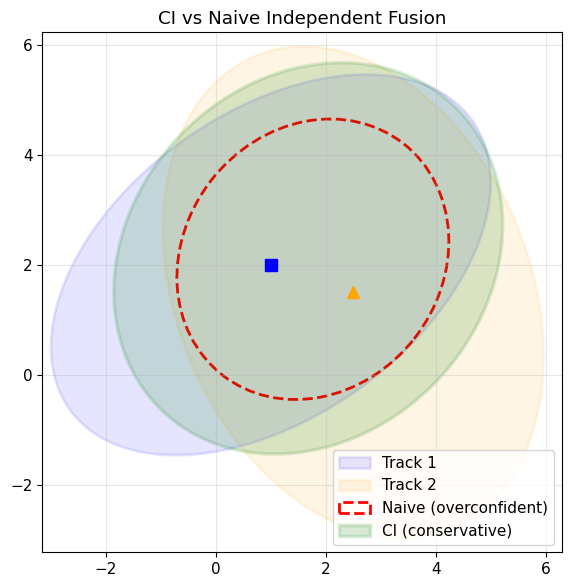

In [ ]:
# --- Covariance Intersection vs Independent Fusion ---
Sig1 = np.array([[4.0, 1.5],[1.5, 3.0]])
Sig2 = np.array([[3.0, -1.0],[-1.0, 5.0]])
mu1_ci = np.array([1.0, 2.0])
mu2_ci = np.array([2.5, 1.5])

# Independent fusion (WRONG if correlated)
Lam_naive = np.linalg.inv(Sig1) + np.linalg.inv(Sig2)
Sig_naive = np.linalg.inv(Lam_naive)
mu_naive = Sig_naive @ (np.linalg.inv(Sig1) @ mu1_ci + np.linalg.inv(Sig2) @ mu2_ci)

# CI: optimise omega
def ci_cost(omega, S1, S2):
    Lam = omega * np.linalg.inv(S1) + (1-omega) * np.linalg.inv(S2)
    return np.trace(np.linalg.inv(Lam))

res = minimize_scalar(lambda w: ci_cost(w, Sig1, Sig2), bounds=(0.01, 0.99), method='bounded')
omega_opt = res.x
Lam_ci = omega_opt*np.linalg.inv(Sig1) + (1-omega_opt)*np.linalg.inv(Sig2)
Sig_ci = np.linalg.inv(Lam_ci)
mu_ci = Sig_ci @ (omega_opt*np.linalg.inv(Sig1)@mu1_ci + (1-omega_opt)*np.linalg.inv(Sig2)@mu2_ci)

print(f"Optimal omega = {omega_opt:.3f}")
print(f"Naive fusion det(Sigma) = {np.linalg.det(Sig_naive):.4f}")
print(f"CI fusion    det(Sigma) = {np.linalg.det(Sig_ci):.4f}")
print(f"CI is more conservative (larger Sigma) -- correct for unknown correlation.")

fig, ax = plt.subplots(figsize=(7, 6))
plot_cov_ellipse(ax, mu1_ci, Sig1, facecolor='blue', alpha=0.1, edgecolor='blue', lw=2, label='Track 1')
plot_cov_ellipse(ax, mu2_ci, Sig2, facecolor='orange', alpha=0.1, edgecolor='orange', lw=2, label='Track 2')
plot_cov_ellipse(ax, mu_naive, Sig_naive, facecolor='none', edgecolor='red', lw=2, ls='--', label='Naive (overconfident)')
plot_cov_ellipse(ax, mu_ci, Sig_ci, facecolor='green', alpha=0.15, edgecolor='green', lw=2.5, label='CI (conservative)')
ax.plot(*mu1_ci, 'bs', ms=8); ax.plot(*mu2_ci, '^', color='orange', ms=8)
ax.set_aspect('equal'); ax.legend(); ax.set_title('CI vs Naive Independent Fusion')
plt.tight_layout(); plt.show()


---
## §8  Product of Experts (PoE) Fusion & Missing Modality

**Slide coverage:** Block 2 — "Product of Experts (PoE) Fusion", "Information Form"

PoE fuses Gaussian expert outputs by adding precisions. A missing modality contributes zero precision.


In [ ]:
# PoE with 3 modalities, one drops out
np.random.seed(7)
x_true_poe = 5.0

modalities = [
    ('IMU',    4.8,  0.5),
    ('GPS',    5.3,  1.5),
    ('Camera', 5.1,  0.8),
]

print("=== PoE Fusion with all modalities ===")
lam_sum = 0; eta_sum = 0
for name, mu_m, var_m in modalities:
    lam = 1/var_m
    eta = lam * mu_m
    lam_sum += lam; eta_sum += eta
    print(f"  {name:8s}: mu={mu_m:.2f}, var={var_m:.2f}, lambda={lam:.3f}")

mu_poe = eta_sum / lam_sum
var_poe = 1 / lam_sum
print(f"  Fused PoE: mu={mu_poe:.4f}, var={var_poe:.4f}, sigma={var_poe**0.5:.4f}")

print("\n=== PoE with GPS dropped (missing modality) ===")
lam_sum2 = 0; eta_sum2 = 0
for name, mu_m, var_m in modalities:
    if name == 'GPS':
        print(f"  {name:8s}: MISSING -- contributes lambda=0 (no info)")
        continue
    lam = 1/var_m; eta = lam * mu_m
    lam_sum2 += lam; eta_sum2 += eta

mu_poe2 = eta_sum2 / lam_sum2
var_poe2 = 1 / lam_sum2
print(f"  Fused PoE: mu={mu_poe2:.4f}, var={var_poe2:.4f}")
print(f"  Uncertainty grew: {var_poe2:.4f} > {var_poe:.4f} -- correct!")


=== PoE Fusion with all modalities ===
  IMU     : mu=4.80, var=0.50, lambda=2.000
  GPS     : mu=5.30, var=1.50, lambda=0.667
  Camera  : mu=5.10, var=0.80, lambda=1.250
  Fused PoE: mu=4.9809, var=0.2553, sigma=0.5053

=== PoE with GPS dropped (missing modality) ===
  GPS     : MISSING -- contributes lambda=0 (no info)
  Fused PoE: mu=4.9154, var=0.3077
  Uncertainty grew: 0.3077 > 0.2553 -- correct!


---
## §9  Ellipsoidal Gating and the Mahalanobis Distance

**Slide coverage:** Block 3 — "Gating: First-Line Rejection", Appendix — "Mahalanobis Distance"

The gate discards implausible measurements:
$$\tilde{y}^T S^{-1} \tilde{y} \leq \gamma, \quad \gamma = \chi^2_{n_y}(P_G)$$


In [ ]:
# --- Gating demo ---
np.random.seed(7)

mu_prior = np.array([10.0, 5.0, 1.0, -0.5])
P_prior = np.array([[4,3,0,0],[3,5,0,0],[0,0,1,0.2],[0,0,0.2,1.5]])
H_gate = np.array([[1,0,0,0],[0,1,0,0]], dtype=float)
R_gate = np.diag([0.5**2, 0.5**2])

yhat = H_gate @ mu_prior
S_gate = H_gate @ P_prior @ H_gate.T + R_gate
S_inv_gate = np.linalg.inv(S_gate)

PG_LIST = [0.95, 0.99, 0.997]
for pg in PG_LIST:
    gamma = chi2.ppf(pg, df=2)
    area = np.pi * gamma * np.sqrt(np.linalg.det(S_gate))
    print(f"  P_G={pg}: gamma={gamma:.3f}, gate area={area:.2f}")

true_samples = np.random.multivariate_normal(yhat, S_gate, 200)
clutter_pts = yhat + np.random.uniform(-8, 8, (200, 2))


  P_G=0.95: gamma=5.991, gate area=68.68
  P_G=0.99: gamma=9.210, gate area=105.57
  P_G=0.997: gamma=11.618, gate area=133.17


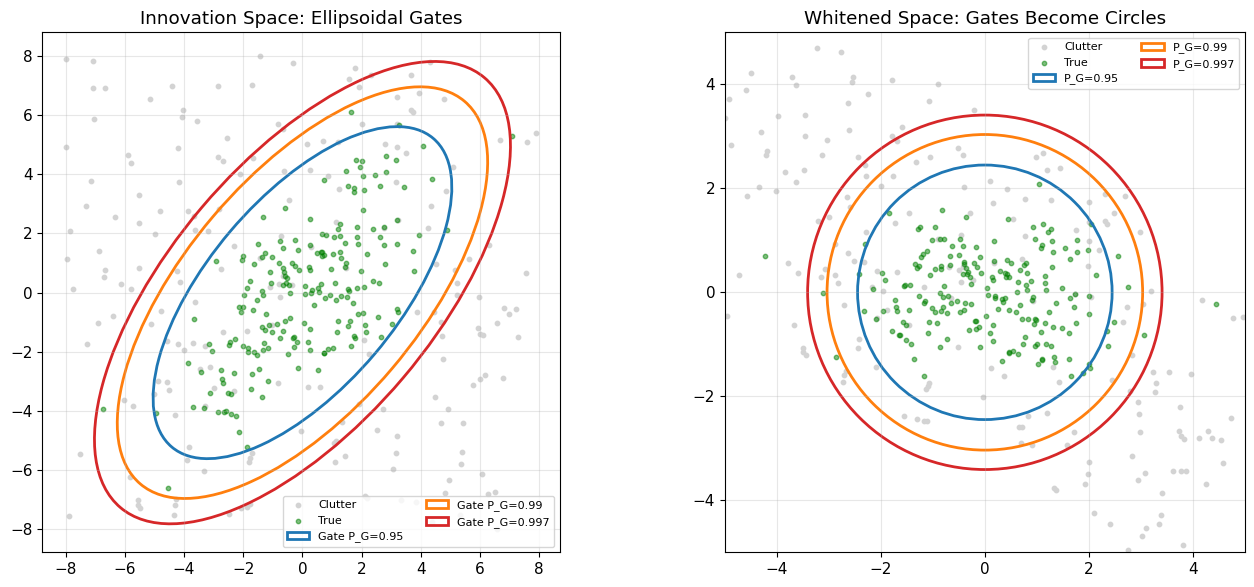


Gate pass-rate verification:
  P_G=0.95: empirical pass rate = 0.970 (expect ~ 0.95)
  P_G=0.99: empirical pass rate = 0.990 (expect ~ 0.99)
  P_G=0.997: empirical pass rate = 0.995 (expect ~ 0.997)


In [ ]:
# Innovation space plot with ellipsoidal gates
def plot_gate_ell(ax, S, center, gamma, **kwargs):
    w, V = np.linalg.eigh(S)
    radii = np.sqrt(gamma) * np.sqrt(w)
    angle = np.degrees(np.arctan2(V[1,1], V[0,1]))
    ell = Ellipse(xy=center, width=2*radii[1], height=2*radii[0],
                  angle=angle, fill=False, **kwargs)
    ax.add_patch(ell)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

r_true = true_samples - yhat
r_clut = clutter_pts - yhat
axes[0].scatter(r_clut[:,0], r_clut[:,1], s=10, c='lightgray', label='Clutter')
axes[0].scatter(r_true[:,0], r_true[:,1], s=10, c='green', alpha=0.5, label='True')
colors = ['tab:blue', 'tab:orange', 'tab:red']
for pg, c in zip(PG_LIST, colors):
    gamma = chi2.ppf(pg, 2)
    plot_gate_ell(axes[0], S_gate, (0,0), gamma, color=c, lw=2, label=f'Gate P_G={pg}')
axes[0].set_aspect('equal'); axes[0].legend(fontsize=8, ncol=2)
axes[0].set_title('Innovation Space: Ellipsoidal Gates')

# Whitened space
Sinvhalf = np.linalg.cholesky(np.linalg.inv(S_gate))
rw_true = r_true @ Sinvhalf.T
rw_clut = r_clut @ Sinvhalf.T
axes[1].scatter(rw_clut[:,0], rw_clut[:,1], s=10, c='lightgray', label='Clutter')
axes[1].scatter(rw_true[:,0], rw_true[:,1], s=10, c='green', alpha=0.5, label='True')
for pg, c in zip(PG_LIST, colors):
    gamma = chi2.ppf(pg, 2)
    circ = plt.Circle((0,0), np.sqrt(gamma), color=c, fill=False, lw=2, label=f'P_G={pg}')
    axes[1].add_patch(circ)
axes[1].set_aspect('equal'); axes[1].legend(fontsize=8, ncol=2)
axes[1].set_title('Whitened Space: Gates Become Circles')
axes[1].set_xlim(-5,5); axes[1].set_ylim(-5,5)

plt.tight_layout(); plt.show()

# Verification
print("\nGate pass-rate verification:")
for pg in PG_LIST:
    gamma = chi2.ppf(pg, 2)
    d2 = np.sum(((true_samples - yhat) @ S_inv_gate) * (true_samples - yhat), axis=1)
    frac = np.mean(d2 <= gamma)
    print(f"  P_G={pg}: empirical pass rate = {frac:.3f} (expect ~ {pg})")


---
## §10  Two Crossing Targets — Simulation Setup

**Slide coverage:** Block 3 — GNN, PDAF, JPDA, MHT


**What this cell sets up**

- **Dynamic model (CV in 2D):**  
  State is `[x, y, vx, vy]`. `F_2d` advances position with constant velocity; `Q_2d` is the discrete white-acceleration covariance (scaled by `0.01`), so process noise is mild → smooth trajectories.
- **Measurement model:**  
  `H_2d` extracts position; `R_2d = diag(1, 1)` ⇒ each axis has σ=1 px (or m) noise.
- **Detection and clutter:**  
  Probability of detection `P_D = 0.9`. Poisson clutter rate `λ = 2e-4` per unit area; FoV area ≈ 4000 ⇒ **expected clutter ≈ 0.8 per frame** (low).  
  → Gates can be generous without letting in too many false alarms.
- **Ground truth:**  
  Two targets start apart in y and move with opposing y‑velocities so they **cross** around mid‑sequence. Process noise is small enough that paths remain well separated except at crossing.



Scenario: 60 steps, 2 crossing targets
Avg measurements/step: 2.6


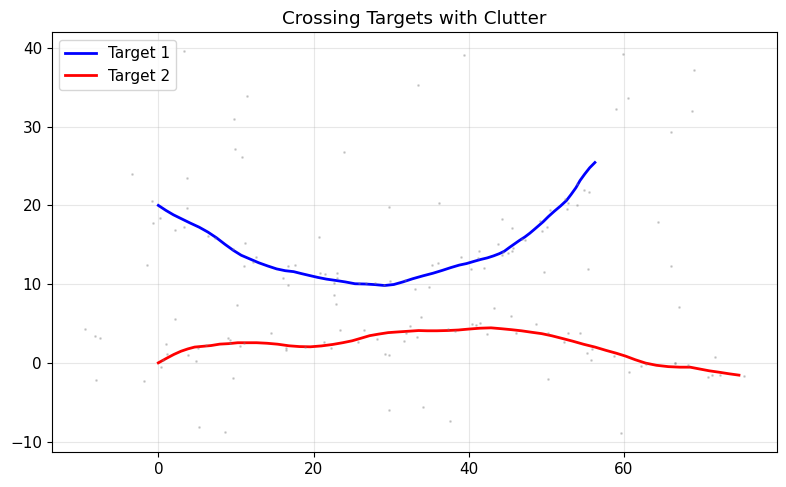

In [ ]:
# --- Crossing target scenario ---
np.random.seed(42)
T_steps = 60
dt_sim = 1.0
F_2d = np.array([[1,0,dt_sim,0],[0,1,0,dt_sim],[0,0,1,0],[0,0,0,1]])
Q_2d = 0.01 * np.array([
    [dt_sim**3/3,0,dt_sim**2/2,0],
    [0,dt_sim**3/3,0,dt_sim**2/2],
    [dt_sim**2/2,0,dt_sim,0],
    [0,dt_sim**2/2,0,dt_sim]
])
H_2d = np.array([[1,0,0,0],[0,1,0,0]], dtype=float)
R_2d = np.diag([1.0, 1.0])
P_D = 0.9
lam_clutter = 0.0002

# True trajectories
states1 = np.zeros((T_steps, 4))
states2 = np.zeros((T_steps, 4))
states1[0] = [0, 20, 1.0, -0.6]
states2[0] = [0, 0, 1.0, 0.6]

for k in range(1, T_steps):
    states1[k] = F_2d @ states1[k-1] + np.random.multivariate_normal(np.zeros(4), Q_2d)
    states2[k] = F_2d @ states2[k-1] + np.random.multivariate_normal(np.zeros(4), Q_2d)

fov = [[-10, 70], [-10, 40]]
fov_area = (fov[0][1]-fov[0][0]) * (fov[1][1]-fov[1][0])

measurements = []
for k in range(T_steps):
    meas_k = []
    for s in [states1[k], states2[k]]:
        if np.random.rand() < P_D:
            z = H_2d @ s + np.random.multivariate_normal(np.zeros(2), R_2d)
            meas_k.append(z)
    n_c = np.random.poisson(lam_clutter * fov_area)
    for _ in range(n_c):
        meas_k.append(np.array([np.random.uniform(fov[0][0], fov[0][1]),
                                 np.random.uniform(fov[1][0], fov[1][1])]))
    measurements.append(meas_k)

print(f"Scenario: {T_steps} steps, 2 crossing targets")
print(f"Avg measurements/step: {np.mean([len(m) for m in measurements]):.1f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(states1[:, 0], states1[:, 1], 'b-', lw=2, label='Target 1')
ax.plot(states2[:, 0], states2[:, 1], 'r-', lw=2, label='Target 2')
for k in range(T_steps):
    for m in measurements[k]:
        ax.plot(m[0], m[1], '.', color='gray', ms=2, alpha=0.3)
ax.set_title('Crossing Targets with Clutter'); ax.legend()
plt.tight_layout(); plt.show()


## §11  Global Nearest Neighbour (GNN)

**What this tracker implements**

- **Per‑step predict** for 2 tracks, then compute a **cost matrix** of squared Mahalanobis distances for all gated measurements.
- Use **Hungarian (linear sum assignment)** to pick a **hard, one‑to‑one assignment** (min total cost).
- **No explicit missed-detection model** or dummy columns; unmatched measurements are simply ignored.
- **Gating:** `d² < gamma_gate` keeps a measurement; otherwise its cost is set very large (`1e9`) to block assignment.

**Why GNN performs well here**

- With low clutter and high detection, the nearest gated measurement is almost always correct—even at crossing—so hard assignment rarely flips tracks.
- Moderate process/measurement noise means innovations are small ⇒ Mahalanobis distances separate cleanly.

**Caveat**

- In heavier clutter / lower `P_D`, hard assignment can latch onto a wrong measurement and cause **track swap**. That’s where PDAF/JPDA/MHT help.


In [ ]:
# --- GNN tracker ---
def run_gnn_tracker(measurements, F, Q, H, R, gamma_gate=16.0):
    n_tracks = 2
    mu = [np.array([measurements[0][i][0], measurements[0][i][1], 0, 0])
          for i in range(min(2, len(measurements[0])))]
    while len(mu) < n_tracks:
        mu.append(mu[-1] + np.array([1,1,0,0]))
    P = [np.eye(4)*10 for _ in range(n_tracks)]
    est = [np.zeros((len(measurements), 4)) for _ in range(n_tracks)]
    for i in range(n_tracks): est[i][0] = mu[i]

    for k in range(1, len(measurements)):
        for i in range(n_tracks):
            mu[i] = F @ mu[i]; P[i] = F @ P[i] @ F.T + Q

        meas_k = measurements[k]; m = len(meas_k)
        cost = np.full((n_tracks, m), 1e9)
        for i in range(n_tracks):
            S = H @ P[i] @ H.T + R; S_inv = np.linalg.inv(S)
            for j in range(m):
                nu = meas_k[j] - H @ mu[i]
                d2 = float(nu @ S_inv @ nu)
                if d2 < gamma_gate: cost[i, j] = d2

        if m > 0:
            ri, ci_arr = linear_sum_assignment(cost)
            for i, j in zip(ri, ci_arr):
                if cost[i, j] < gamma_gate:
                    S = H @ P[i] @ H.T + R
                    K = P[i] @ H.T @ np.linalg.inv(S)
                    mu[i] = mu[i] + K @ (meas_k[j] - H @ mu[i])
                    P[i] = (np.eye(4) - K @ H) @ P[i]
        for i in range(n_tracks): est[i][k] = mu[i]
    return est

est_gnn = run_gnn_tracker(measurements, F_2d, Q_2d, H_2d, R_2d)
rmse1_gnn = np.sqrt(np.mean((est_gnn[0][:,0:2] - states1[:,0:2])**2))
rmse2_gnn = np.sqrt(np.mean((est_gnn[1][:,0:2] - states2[:,0:2])**2))
print(f"GNN RMSE: Track 1 = {rmse1_gnn:.2f}, Track 2 = {rmse2_gnn:.2f}")


GNN RMSE: Track 1 = 0.68, Track 2 = 0.69


## §12  PDAF: Probabilistic Data Association Filter

Computes association probability $\beta_j$ for each gated measurement. The **spread term** inflates covariance.

## 12) PDAF — Probabilistic Data Association Filter

**What this tracker implements**

- **Per‑track, soft association:**  
  For each track i, compute association probabilities **β\_j** over **its gated** measurements (no one‑to‑one coupling to other tracks).  
  The update uses the **probability‑weighted innovation** `ν̄ = Σ β_j ν_j`.
- **Covariance inflation (“spread term”):**  
  Adds $K \left[\sum \beta_j \nu_j \nu_j^\top - \nū \nū^\top\right] K^\top$ plus a **missed detection weight** `β₀` to remain conservative under uncertainty.
- **Clutter model:**  
  Uses a simple normalizer with `λ_clutter` and an approximate gate probability (hardcoded `0.997`), giving reasonable β’s for this scenario.

**Why PDAF ≈ GNN here**

- With few distractors, the probability mass **collapses onto the true measurement** (β’s near one‑hot), so PDAF behaves like KF with the correct measurement—very close to GNN’s result.
- Extra covariance inflation is small because residual spread is small.




In [ ]:
# --- PDAF tracker ---
def run_pdaf_tracker(measurements, F, Q, H, R, P_D, lam_c, gamma_gate=16.0):
    n_tracks = 2
    mu = [np.array([measurements[0][i][0], measurements[0][i][1], 0, 0])
          for i in range(min(2, len(measurements[0])))]
    while len(mu) < n_tracks: mu.append(mu[-1]+np.array([1,1,0,0]))
    P_list = [np.eye(4)*10 for _ in range(n_tracks)]
    est = [np.zeros((len(measurements), 4)) for _ in range(n_tracks)]
    P_hist = [np.zeros(len(measurements)) for _ in range(n_tracks)]
    for i in range(n_tracks): est[i][0]=mu[i]; P_hist[i][0]=np.trace(P_list[i])

    for k in range(1, len(measurements)):
        for i in range(n_tracks):
            mu[i] = F @ mu[i]; P_list[i] = F @ P_list[i] @ F.T + Q
            S = H @ P_list[i] @ H.T + R; S_inv = np.linalg.inv(S)
            K = P_list[i] @ H.T @ S_inv; yhat_i = H @ mu[i]

            gated = []
            for z in measurements[k]:
                nu = z - yhat_i; d2 = float(nu @ S_inv @ nu)
                if d2 < gamma_gate: gated.append((z, nu))

            if len(gated) == 0:
                est[i][k]=mu[i]; P_hist[i][k]=np.trace(P_list[i]); continue

            L = [multivariate_normal.pdf(z, mean=yhat_i, cov=S) for z, _ in gated]
            c_bar = 1 - P_D * 0.997
            denom = lam_c * c_bar + P_D * sum(L)
            betas = [P_D * l / denom for l in L]
            beta0 = lam_c * c_bar / denom

            nu_bar = sum(b * nu for b, (_, nu) in zip(betas, gated))
            mu[i] = mu[i] + K @ nu_bar

            P_kf = (np.eye(4) - K @ H) @ P_list[i]
            spread = sum(b * np.outer(nu, nu) for b, (_, nu) in zip(betas, gated))
            spread -= np.outer(nu_bar, nu_bar)
            P_list[i] = beta0 * P_list[i] + (1-beta0) * P_kf + K @ spread @ K.T

            est[i][k]=mu[i]; P_hist[i][k]=np.trace(P_list[i])
    return est, P_hist

est_pdaf, P_pdaf = run_pdaf_tracker(measurements, F_2d, Q_2d, H_2d, R_2d, P_D, lam_clutter)
rmse1_pdaf = np.sqrt(np.mean((est_pdaf[0][:,0:2] - states1[:,0:2])**2))
rmse2_pdaf = np.sqrt(np.mean((est_pdaf[1][:,0:2] - states2[:,0:2])**2))
print(f"PDAF RMSE: Track 1 = {rmse1_pdaf:.2f}, Track 2 = {rmse2_pdaf:.2f}")


PDAF RMSE: Track 1 = 0.68, Track 2 = 0.70


## §13  JPDA: Joint Probabilistic Data Association

JPDA enforces the one-to-one constraint. If Track 1 claims measurement j strongly, Track 2's claim is suppressed.

**What this tracker implements**

- **Joint events over two tracks:**  
  Enumerates feasible measurement‑to‑track assignments (including “0” for missed detection), enforcing **one‑to‑one exclusivity** across tracks at a time step.
- **Event scoring:**  
  Each joint hypothesis gets a likelihood score using per‑track Gaussian likelihoods, `P_D`, and a simple clutter factor `λ_c`.  
  Normalize to get **joint probabilities**, then **marginalize** to per‑track β’s.
- **Update:**  
  Same PDAF‑style mean update with β‑weighted innovation and covariance spread term, **but β’s now respect mutual exclusivity** across tracks.

**Why JPDA ≈ PDAF/GNN here**

- With only 2 tracks and a clean scene, the highest joint event is typically the obvious assignment; JPDA collapses to the same outcome as GNN/PDAF.
- The main benefit (suppressing **coalescence** around crossing) is muted because SNR is high and clutter is light.

**Complexity note**

- This implementation enumerates joint events explicitly. That is fine for 2 tracks; with many tracks, enumeration explodes—use efficient JPDA variants or MHT.
``


In [ ]:
# --- JPDA tracker (simplified) ---
from itertools import product as iter_product

def run_jpda_tracker(measurements, F, Q, H, R, P_D, lam_c, gamma_gate=16.0):
    n_tracks = 2
    mu = [np.array([measurements[0][i][0], measurements[0][i][1], 0, 0])
          for i in range(min(2, len(measurements[0])))]
    while len(mu) < n_tracks: mu.append(mu[-1]+np.array([1,1,0,0]))
    P_list = [np.eye(4)*10 for _ in range(n_tracks)]
    est = [np.zeros((len(measurements), 4)) for _ in range(n_tracks)]
    P_hist = [np.zeros(len(measurements)) for _ in range(n_tracks)]
    for i in range(n_tracks): est[i][0]=mu[i]; P_hist[i][0]=np.trace(P_list[i])

    for k in range(1, len(measurements)):
        S_list, S_inv_list, K_list, yhat_list = [], [], [], []
        for i in range(n_tracks):
            mu[i] = F @ mu[i]; P_list[i] = F @ P_list[i] @ F.T + Q
            S = H @ P_list[i] @ H.T + R
            S_list.append(S); S_inv_list.append(np.linalg.inv(S))
            K_list.append(P_list[i] @ H.T @ np.linalg.inv(S))
            yhat_list.append(H @ mu[i])

        meas_k = measurements[k]; m = len(meas_k)
        gated_idx = []
        for i in range(n_tracks):
            gi = []
            for j in range(m):
                nu = meas_k[j] - yhat_list[i]
                d2 = float(nu @ S_inv_list[i] @ nu)
                if d2 < gamma_gate: gi.append(j)
            gated_idx.append(gi)

        all_gated = list(set(j for gi in gated_idx for j in gi))
        if len(all_gated) == 0:
            for i in range(n_tracks): est[i][k]=mu[i]; P_hist[i][k]=np.trace(P_list[i])
            continue

        assignments = []
        for i in range(n_tracks):
            assignments.append([0] + [j+1 for j in gated_idx[i]])

        joint_events = []
        for combo in iter_product(*assignments):
            assigned = [c for c in combo if c > 0]
            if len(assigned) == len(set(assigned)):
                joint_events.append(combo)

        scores = []
        for combo in joint_events:
            log_score = 0.0
            for i, c in enumerate(combo):
                if c == 0:
                    log_score += np.log(1 - P_D + 1e-30)
                else:
                    j = c - 1
                    lik = multivariate_normal.pdf(meas_k[j], mean=yhat_list[i], cov=S_list[i])
                    log_score += np.log(P_D * lik + 1e-30) - np.log(lam_c + 1e-30)
            scores.append(np.exp(log_score))

        total = sum(scores)
        if total < 1e-30:
            for i in range(n_tracks): est[i][k]=mu[i]; P_hist[i][k]=np.trace(P_list[i])
            continue
        probs = [s/total for s in scores]

        for i in range(n_tracks):
            beta = {}
            for combo, p in zip(joint_events, probs):
                c = combo[i]; beta[c] = beta.get(c, 0) + p
            beta0 = beta.get(0, 0)
            nu_bar = np.zeros(2)
            for c, b in beta.items():
                if c > 0: nu_bar += b * (meas_k[c-1] - yhat_list[i])

            mu[i] = mu[i] + K_list[i] @ nu_bar
            P_kf = (np.eye(4) - K_list[i] @ H) @ P_list[i]
            spread = np.zeros((2, 2))
            for c, b in beta.items():
                if c > 0:
                    nu = meas_k[c-1] - yhat_list[i]
                    spread += b * np.outer(nu, nu)
            spread -= np.outer(nu_bar, nu_bar)
            P_list[i] = beta0 * P_list[i] + (1-beta0) * P_kf + K_list[i] @ spread @ K_list[i].T
            est[i][k]=mu[i]; P_hist[i][k]=np.trace(P_list[i])
    return est, P_hist

est_jpda, P_jpda = run_jpda_tracker(measurements, F_2d, Q_2d, H_2d, R_2d, P_D, lam_clutter)


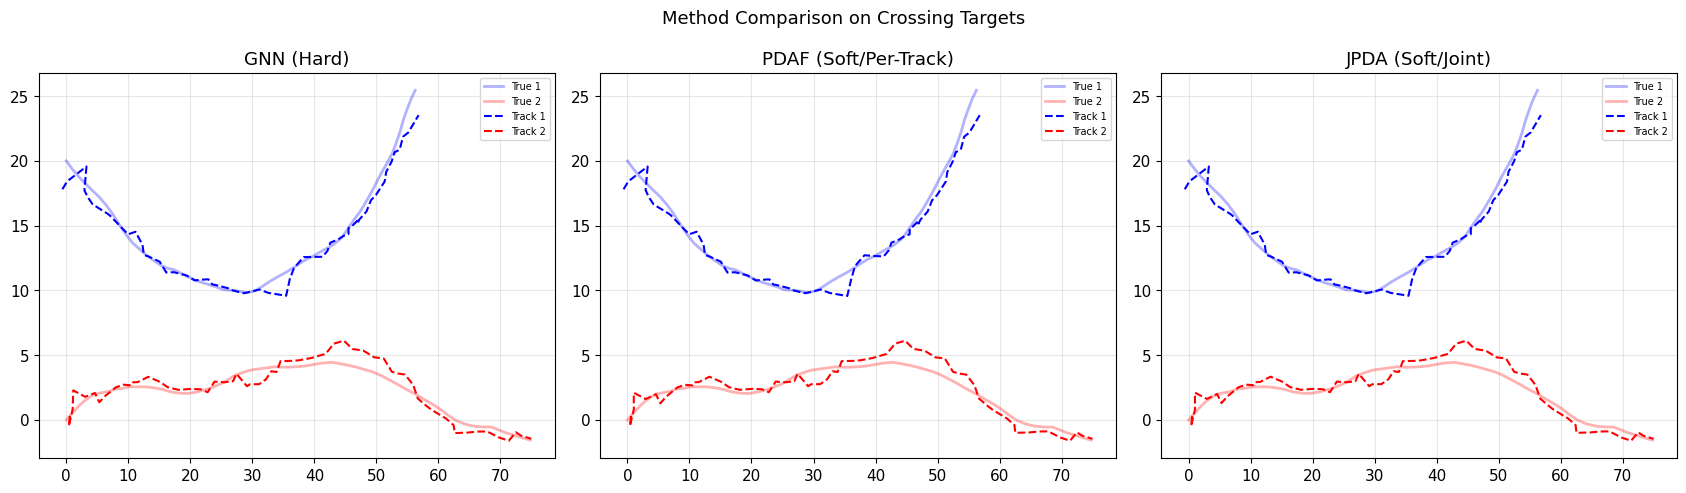


RMSE Comparison:
  GNN: Track 1 = 0.68, Track 2 = 0.69, Avg = 0.69
  PDAF: Track 1 = 0.68, Track 2 = 0.70, Avg = 0.69
  JPDA: Track 1 = 0.68, Track 2 = 0.70, Avg = 0.69

Method     Assign         Cov Infl     Inter-trk    Crossing  
-----------------------------------------------------------------
GNN        Hard           No           No           Poor      
PDAF       Soft/per-trk   Yes          No           Coalesc.  
JPDA       Soft/joint     Yes          Yes          Good      
MHT        Deferred       Yes          Yes          Best      


In [ ]:
# Compare all three
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
titles = ['GNN (Hard)', 'PDAF (Soft/Per-Track)', 'JPDA (Soft/Joint)']
ests_all = [est_gnn, est_pdaf, est_jpda]
for ax, title, e in zip(axes, titles, ests_all):
    ax.plot(states1[:,0], states1[:,1], 'b-', lw=2, alpha=0.3, label='True 1')
    ax.plot(states2[:,0], states2[:,1], 'r-', lw=2, alpha=0.3, label='True 2')
    ax.plot(e[0][:,0], e[0][:,1], 'b--', lw=1.5, label='Track 1')
    ax.plot(e[1][:,0], e[1][:,1], 'r--', lw=1.5, label='Track 2')
    ax.set_title(title); ax.legend(fontsize=7)
plt.suptitle('Method Comparison on Crossing Targets', fontsize=13)
plt.tight_layout(); plt.show()

print("\nRMSE Comparison:")
for name, e in zip(['GNN', 'PDAF', 'JPDA'], ests_all):
    r1 = np.sqrt(np.mean((e[0][:,0:2] - states1[:,0:2])**2))
    r2 = np.sqrt(np.mean((e[1][:,0:2] - states2[:,0:2])**2))
    print(f"  {name}: Track 1 = {r1:.2f}, Track 2 = {r2:.2f}, Avg = {(r1+r2)/2:.2f}")

print("\n" + "="*65)
print(f"{'Method':<10} {'Assign':<14} {'Cov Infl':<12} {'Inter-trk':<12} {'Crossing':<10}")
print("-"*65)
print(f"{'GNN':<10} {'Hard':<14} {'No':<12} {'No':<12} {'Poor':<10}")
print(f"{'PDAF':<10} {'Soft/per-trk':<14} {'Yes':<12} {'No':<12} {'Coalesc.':<10}")
print(f"{'JPDA':<10} {'Soft/joint':<14} {'Yes':<12} {'Yes':<12} {'Good':<10}")
print(f"{'MHT':<10} {'Deferred':<14} {'Yes':<12} {'Yes':<12} {'Best':<10}")
